In [1]:
%load_ext autoreload
%autoreload 1

Exploring Sentiment Data

In [1]:
import pandas as pd

In [8]:
df = pd.read_csv("sentiment_analysis\cleaned_Bloomberg_Transcript_Results.csv")

In [9]:
df

,Date,Information Technology,Health Care,Financials,Consumer Discretionary,Communication Services,Industrials,Consumer Staples,Energy,Utilities,Real Estate,Materials
0,2024-01-06,0.41,0.28,0.35,0.15,0.32,0.06,0.18,0.22,-0.03,0.02,-0.08
1,2024-01-22,0.75,0.45,0.25,0.40,0.50,0.20,0.35,0.15,0.10,-0.05,0.10
2,2024-01-23,0.62,0.18,0.74,0.56,0.68,0.31,0.12,-0.08,0.05,0.22,0.14
3,2024-01-24,0.45,0.22,0.33,0.32,0.44,0.37,0.18,0.41,0.29,0.17,0.24
4,2024-01-24,0.84,0.05,0.08,0.48,0.82,0.14,0.12,-0.18,0.02,0.21,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...
537,2026-03-18,0.20,-0.05,-0.15,-0.10,0.15,0.10,-0.35,0.85,-0.05,-0.25,0.25
538,2026-03-18,-0.10,-0.05,-0.20,-0.35,-0.05,-0.25,-0.15,0.65,-0.15,-0.25,0.15
539,2026-03-19,0.14,0.05,-0.18,-0.12,NaN,-0.22,-0.06,0.82,-0.16,-0.25,-0.31
540,2026-03-20,-0.25,0.05,-0.15,-0.35,0.05,-0.10,0.10,0.90,0.10,-0.20,-0.05


In [10]:
#Removing 5 entries with missing data
df2 = df.drop(df.loc[df["Date"] == "MISSING"].index)#5 Entries w no dates, removing from data

In [12]:
df2

,Date,Information Technology,Health Care,Financials,Consumer Discretionary,Communication Services,Industrials,Consumer Staples,Energy,Utilities,Real Estate,Materials
0,2024-01-06,0.41,0.28,0.35,0.15,0.32,0.06,0.18,0.22,-0.03,0.02,-0.08
1,2024-01-22,0.75,0.45,0.25,0.40,0.50,0.20,0.35,0.15,0.10,-0.05,0.10
2,2024-01-23,0.62,0.18,0.74,0.56,0.68,0.31,0.12,-0.08,0.05,0.22,0.14
3,2024-01-24,0.45,0.22,0.33,0.32,0.44,0.37,0.18,0.41,0.29,0.17,0.24
4,2024-01-24,0.84,0.05,0.08,0.48,0.82,0.14,0.12,-0.18,0.02,0.21,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...
537,2026-03-18,0.20,-0.05,-0.15,-0.10,0.15,0.10,-0.35,0.85,-0.05,-0.25,0.25
538,2026-03-18,-0.10,-0.05,-0.20,-0.35,-0.05,-0.25,-0.15,0.65,-0.15,-0.25,0.15
539,2026-03-19,0.14,0.05,-0.18,-0.12,NaN,-0.22,-0.06,0.82,-0.16,-0.25,-0.31
540,2026-03-20,-0.25,0.05,-0.15,-0.35,0.05,-0.10,0.10,0.90,0.10,-0.20,-0.05


In [14]:
#Converting Date col. to pd.date_time dtype
df2['Date'] = pd.to_datetime(df2['Date'])

print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    542 non-null    datetime64[ns]
 1   Information Technology  532 non-null    float64       
 2   Health Care             532 non-null    float64       
 3   Financials              533 non-null    float64       
 4   Consumer Discretionary  532 non-null    float64       
 5   Communication Services  523 non-null    float64       
 6   Industrials             533 non-null    float64       
 7   Consumer Staples        532 non-null    float64       
 8   Energy                  533 non-null    float64       
 9   Utilities               533 non-null    float64       
 10  Real Estate             532 non-null    float64       
 11  Materials               533 non-null    float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 50

In [15]:
df3 = df2.sort_values(by="Date")
df3

,Date,Information Technology,Health Care,Financials,Consumer Discretionary,Communication Services,Industrials,Consumer Staples,Energy,Utilities,Real Estate,Materials
0,2024-01-06,0.41,0.28,0.35,0.15,0.32,0.06,0.18,0.22,-0.03,0.02,-0.08
1,2024-01-22,0.75,0.45,0.25,0.40,0.50,0.20,0.35,0.15,0.10,-0.05,0.10
2,2024-01-23,0.62,0.18,0.74,0.56,0.68,0.31,0.12,-0.08,0.05,0.22,0.14
3,2024-01-24,0.45,0.22,0.33,0.32,0.44,0.37,0.18,0.41,0.29,0.17,0.24
4,2024-01-24,0.84,0.05,0.08,0.48,0.82,0.14,0.12,-0.18,0.02,0.21,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...
537,2026-03-18,0.20,-0.05,-0.15,-0.10,0.15,0.10,-0.35,0.85,-0.05,-0.25,0.25
538,2026-03-18,-0.10,-0.05,-0.20,-0.35,-0.05,-0.25,-0.15,0.65,-0.15,-0.25,0.15
539,2026-03-19,0.14,0.05,-0.18,-0.12,NaN,-0.22,-0.06,0.82,-0.16,-0.25,-0.31
540,2026-03-20,-0.25,0.05,-0.15,-0.35,0.05,-0.10,0.10,0.90,0.10,-0.20,-0.05


In [6]:
df3.to_csv("sentiment_analysis\cleaned_Bloomberg_Transcript_Results.csv", index=False)

Collect Realized Volatility Data

In [ ]:
"""  
🔑 SPDR Select Sector ETF Tickers (most commonly used)
XLC — Communication Services
XLY — Consumer Discretionary
XLP — Consumer Staples
XLE — Energy
XLF — Financials
XLV — Health Care
XLI — Industrials
XLK — Information Technology
XLB — Materials
XLRE — Real Estate
"""

In [ ]:
from TickerData import YF_TickerData
ticker_lst = ["XLC", "XLY", "XLP", "XLE", "XLF", "XLV", "XLI", "XLK", "XLB", "XLRE"]
alpha = YF_TickerData(ticker_lst)

start_date = "2024-01-06"
end_date = "2026-03-24"

lag = 5 #Number of days used to compute volatiliy "stdev"

response = alpha.GetData(start_date, end_date, lag)


[*********************100%***********************]  1 of 1 completed
ERROR: 
1 Failed download:
ERROR: ['XLC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
INFO: Tickers Processed: 1/10


In [2]:
response

,Date,XLC Closing Price,XLC Log Return,XLC Volatility,XLY Closing Price,XLY Log Return,XLY Volatility,XLP Closing Price,XLP Log Return,XLP Volatility,...,XLI Volatility,XLK Closing Price,XLK Log Return,XLK Volatility,XLB Closing Price,XLB Log Return,XLB Volatility,XLRE Closing Price,XLRE Log Return,XLRE Volatility
0,2024-01-16,71.488655,-0.005706,0.006231,85.253304,-0.001150,0.007173,68.164833,-0.005510,0.003562,...,0.005506,94.993050,0.002494,0.002728,39.542645,-0.011571,0.005881,36.455479,-0.006088,0.007059
1,2024-01-17,71.050308,-0.006151,0.006905,84.507530,-0.008786,0.007797,68.117752,-0.000691,0.003148,...,0.005902,94.524796,-0.004942,0.004940,39.255028,-0.007300,0.005001,35.787598,-0.018490,0.010050
2,2024-01-18,71.917236,0.012128,0.007926,84.988365,0.005674,0.007011,68.033005,-0.001245,0.003103,...,0.009046,96.442207,0.020082,0.009159,39.379662,0.003170,0.006004,35.555687,-0.006501,0.009374
3,2024-01-19,72.891335,0.013454,0.009395,85.807739,0.009595,0.009224,67.835312,-0.002910,0.003183,...,0.009612,98.665222,0.022789,0.012068,39.418011,0.000973,0.006348,35.898907,0.009607,0.011545
4,2024-01-22,73.037468,0.002003,0.009394,85.429932,-0.004413,0.007451,67.505775,-0.004870,0.002133,...,0.010095,99.098984,0.004387,0.011947,39.533054,0.002914,0.006685,36.065884,0.004641,0.010936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,2026-03-17,115.003014,0.000347,0.008404,112.953094,0.008696,0.013936,84.225914,-0.003300,0.007352,...,0.012842,139.366714,0.005461,0.012870,49.300755,0.002426,0.005540,42.434780,0.003283,0.008022
544,2026-03-18,113.298454,-0.014933,0.009835,110.348328,-0.023331,0.016858,82.177444,-0.024622,0.011897,...,0.012924,137.788681,-0.011387,0.013294,48.265358,-0.021225,0.010369,41.739452,-0.016522,0.009680
545,2026-03-19,112.780106,-0.004586,0.008429,109.480072,-0.007899,0.014211,81.511192,-0.008141,0.011984,...,0.006926,138.258087,0.003401,0.010384,47.528637,-0.015382,0.011091,41.640118,-0.002383,0.009371
546,2026-03-20,111.873001,-0.008076,0.008534,107.524002,-0.018028,0.015722,80.834999,-0.008330,0.010189,...,0.009192,135.121994,-0.022944,0.014827,46.771999,-0.016048,0.011684,40.319000,-0.032241,0.016341


In [4]:
import pandas as pd
response["Date"] = pd.to_datetime(response["Date"])

In [6]:
response2 = response.loc[(response["Date"] >= "2024-01-06") & (response["Date"] <= "2026-03-24")]

In [7]:
response2

,Date,XLC Closing Price,XLC Log Return,XLC Volatility,XLY Closing Price,XLY Log Return,XLY Volatility,XLP Closing Price,XLP Log Return,XLP Volatility,...,XLI Volatility,XLK Closing Price,XLK Log Return,XLK Volatility,XLB Closing Price,XLB Log Return,XLB Volatility,XLRE Closing Price,XLRE Log Return,XLRE Volatility
0,2024-01-16,71.488655,-0.005706,0.006231,85.253304,-0.001150,0.007173,68.164833,-0.005510,0.003562,...,0.005506,94.993050,0.002494,0.002728,39.542645,-0.011571,0.005881,36.455479,-0.006088,0.007059
1,2024-01-17,71.050308,-0.006151,0.006905,84.507530,-0.008786,0.007797,68.117752,-0.000691,0.003148,...,0.005902,94.524796,-0.004942,0.004940,39.255028,-0.007300,0.005001,35.787598,-0.018490,0.010050
2,2024-01-18,71.917236,0.012128,0.007926,84.988365,0.005674,0.007011,68.033005,-0.001245,0.003103,...,0.009046,96.442207,0.020082,0.009159,39.379662,0.003170,0.006004,35.555687,-0.006501,0.009374
3,2024-01-19,72.891335,0.013454,0.009395,85.807739,0.009595,0.009224,67.835312,-0.002910,0.003183,...,0.009612,98.665222,0.022789,0.012068,39.418011,0.000973,0.006348,35.898907,0.009607,0.011545
4,2024-01-22,73.037468,0.002003,0.009394,85.429932,-0.004413,0.007451,67.505775,-0.004870,0.002133,...,0.010095,99.098984,0.004387,0.011947,39.533054,0.002914,0.006685,36.065884,0.004641,0.010936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,2026-03-17,115.003014,0.000347,0.008404,112.953094,0.008696,0.013936,84.225914,-0.003300,0.007352,...,0.012842,139.366714,0.005461,0.012870,49.300755,0.002426,0.005540,42.434780,0.003283,0.008022
544,2026-03-18,113.298454,-0.014933,0.009835,110.348328,-0.023331,0.016858,82.177444,-0.024622,0.011897,...,0.012924,137.788681,-0.011387,0.013294,48.265358,-0.021225,0.010369,41.739452,-0.016522,0.009680
545,2026-03-19,112.780106,-0.004586,0.008429,109.480072,-0.007899,0.014211,81.511192,-0.008141,0.011984,...,0.006926,138.258087,0.003401,0.010384,47.528637,-0.015382,0.011091,41.640118,-0.002383,0.009371
546,2026-03-20,111.873001,-0.008076,0.008534,107.524002,-0.018028,0.015722,80.834999,-0.008330,0.010189,...,0.009192,135.121994,-0.022944,0.014827,46.771999,-0.016048,0.011684,40.319000,-0.032241,0.016341


In [ ]:
#Joining Sentiment and Ticker Data to 1 CSV
sentiment_df = pd.read_csv("sentiment_analysis\cleaned_Bloomberg_Transcript_Results.csv")

In [19]:
# Convert 'Date' in both DataFrames to datetime objects
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date'])
response2['Date'] = pd.to_datetime(response2['Date'])

# Now the merge will work
merged_df = pd.merge(sentiment_df, response2, on='Date', how='left')

In [20]:
merged_df

,Date,Information Technology,Health Care,Financials,Consumer Discretionary,Communication Services,Industrials,Consumer Staples,Energy,Utilities,...,XLI Volatility,XLK Closing Price,XLK Log Return,XLK Volatility,XLB Closing Price,XLB Log Return,XLB Volatility,XLRE Closing Price,XLRE Log Return,XLRE Volatility
0,2024-01-06,0.41,0.28,0.35,0.15,0.32,0.06,0.18,0.22,-0.03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-22,0.75,0.45,0.25,0.40,0.50,0.20,0.35,0.15,0.10,...,0.010095,99.098984,0.004387,0.011947,39.533054,0.002914,0.006685,36.065884,0.004641,0.010936
2,2024-01-23,0.62,0.18,0.74,0.56,0.68,0.31,0.12,-0.08,0.05,...,0.007876,99.498222,0.004021,0.011758,39.662483,0.003269,0.004518,35.871078,-0.005416,0.010898
3,2024-01-24,0.45,0.22,0.33,0.32,0.44,0.37,0.18,0.41,0.29,...,0.007679,100.183365,0.006862,0.009070,39.125599,-0.013629,0.007310,35.379444,-0.013800,0.009348
4,2024-01-24,0.84,0.05,0.08,0.48,0.82,0.14,0.12,-0.18,0.02,...,0.007679,100.183365,0.006862,0.009070,39.125599,-0.013629,0.007310,35.379444,-0.013800,0.009348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,2026-03-18,0.20,-0.05,-0.15,-0.10,0.15,0.10,-0.35,0.85,-0.05,...,0.012924,137.788681,-0.011387,0.013294,48.265358,-0.021225,0.010369,41.739452,-0.016522,0.009680
538,2026-03-18,-0.10,-0.05,-0.20,-0.35,-0.05,-0.25,-0.15,0.65,-0.15,...,0.012924,137.788681,-0.011387,0.013294,48.265358,-0.021225,0.010369,41.739452,-0.016522,0.009680
539,2026-03-19,0.14,0.05,-0.18,-0.12,NaN,-0.22,-0.06,0.82,-0.16,...,0.006926,138.258087,0.003401,0.010384,47.528637,-0.015382,0.011091,41.640118,-0.002383,0.009371
540,2026-03-20,-0.25,0.05,-0.15,-0.35,0.05,-0.10,0.10,0.90,0.10,...,0.009192,135.121994,-0.022944,0.014827,46.771999,-0.016048,0.011684,40.319000,-0.032241,0.016341


In [21]:
df_clean = merged_df.dropna()

In [23]:
df_clean_sorted = df_clean.sort_values(by="Date")

In [24]:
df_clean_sorted

,Date,Information Technology,Health Care,Financials,Consumer Discretionary,Communication Services,Industrials,Consumer Staples,Energy,Utilities,...,XLI Volatility,XLK Closing Price,XLK Log Return,XLK Volatility,XLB Closing Price,XLB Log Return,XLB Volatility,XLRE Closing Price,XLRE Log Return,XLRE Volatility
1,2024-01-22,0.75,0.45,0.25,0.40,0.50,0.20,0.35,0.15,0.10,...,0.010095,99.098984,0.004387,0.011947,39.533054,0.002914,0.006685,36.065884,0.004641,0.010936
2,2024-01-23,0.62,0.18,0.74,0.56,0.68,0.31,0.12,-0.08,0.05,...,0.007876,99.498222,0.004021,0.011758,39.662483,0.003269,0.004518,35.871078,-0.005416,0.010898
3,2024-01-24,0.45,0.22,0.33,0.32,0.44,0.37,0.18,0.41,0.29,...,0.007679,100.183365,0.006862,0.009070,39.125599,-0.013629,0.007310,35.379444,-0.013800,0.009348
4,2024-01-24,0.84,0.05,0.08,0.48,0.82,0.14,0.12,-0.18,0.02,...,0.007679,100.183365,0.006862,0.009070,39.125599,-0.013629,0.007310,35.379444,-0.013800,0.009348
5,2024-01-25,0.20,0.08,0.18,-0.08,0.12,-0.22,0.02,0.15,0.04,...,0.006631,100.602348,0.004173,0.008101,39.537849,0.010481,0.008839,35.861801,0.013542,0.011206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,2026-03-16,0.15,0.05,-0.35,-0.10,0.10,-0.15,0.05,0.85,0.00,...,0.012263,138.607666,0.014370,0.012484,49.181286,0.004260,0.005100,42.295715,0.007780,0.007673
536,2026-03-17,0.55,0.10,-0.20,0.35,0.25,-0.05,-0.10,0.75,-0.05,...,0.012842,139.366714,0.005461,0.012870,49.300755,0.002426,0.005540,42.434780,0.003283,0.008022
537,2026-03-18,0.20,-0.05,-0.15,-0.10,0.15,0.10,-0.35,0.85,-0.05,...,0.012924,137.788681,-0.011387,0.013294,48.265358,-0.021225,0.010369,41.739452,-0.016522,0.009680
538,2026-03-18,-0.10,-0.05,-0.20,-0.35,-0.05,-0.25,-0.15,0.65,-0.15,...,0.012924,137.788681,-0.011387,0.013294,48.265358,-0.021225,0.010369,41.739452,-0.016522,0.009680


In [25]:
df_clean_sorted.to_csv("./TickerData/merged_sentiment_ticker.csv", index=False)

Sentiment Score Time Series In Relation To Specific SP500 Core Sectors

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

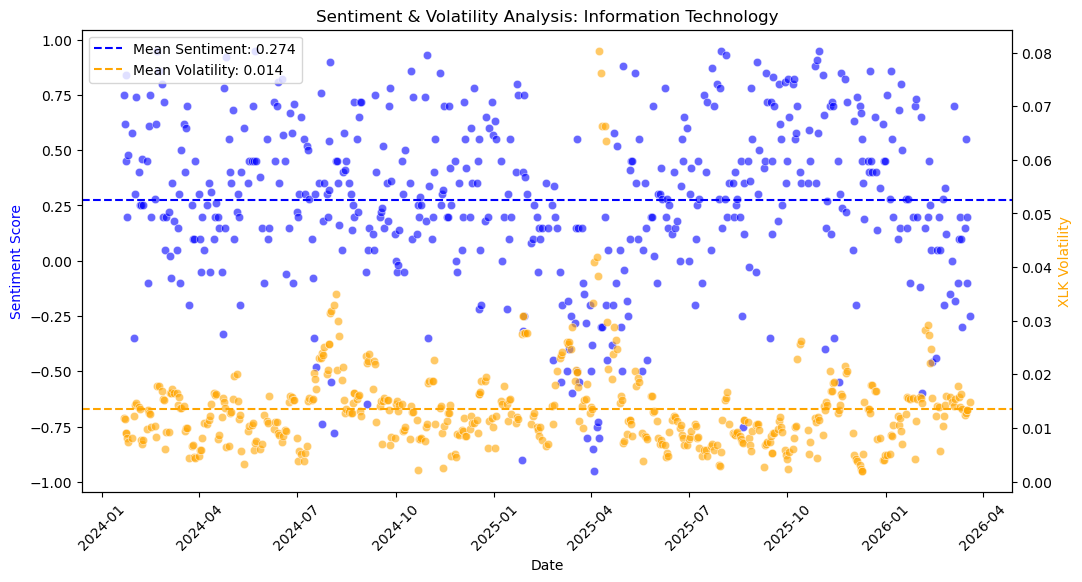

In [ ]:
col_title = "Information Technology"

ticker_vol_title = "XLK Volatility"

# 1. Calculate the means
sent_mean = df_clean_sorted[col_title].mean()
vol_mean = df_clean_sorted[ticker_vol_title].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot Sentiment (Left Axis)
sns.scatterplot(data=df_clean_sorted, x="Date", y=col_title, ax=ax1, color='blue', alpha=0.6)
ax1.axhline(sent_mean, color="blue", linestyle="--", label=f"Mean Sentiment: {sent_mean:.3f}")
ax1.set_ylabel("Sentiment Score", color='blue')

# 3. Create Volatility (Right Axis)
ax2 = ax1.twinx()
sns.scatterplot(data=df_clean_sorted, x="Date", y=ticker_vol_title , ax=ax2, color='orange', alpha=0.6)
ax2.axhline(vol_mean, color="orange", linestyle="--", label=f"Mean Volatility: {vol_mean:.3f}")
ax2.set_ylabel(ticker_vol_title, color='orange')

# 4. Cleanup
plt.title(f"Sentiment & Volatility Analysis: {col_title}")
ax1.tick_params(axis='x', rotation=45)

# Combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

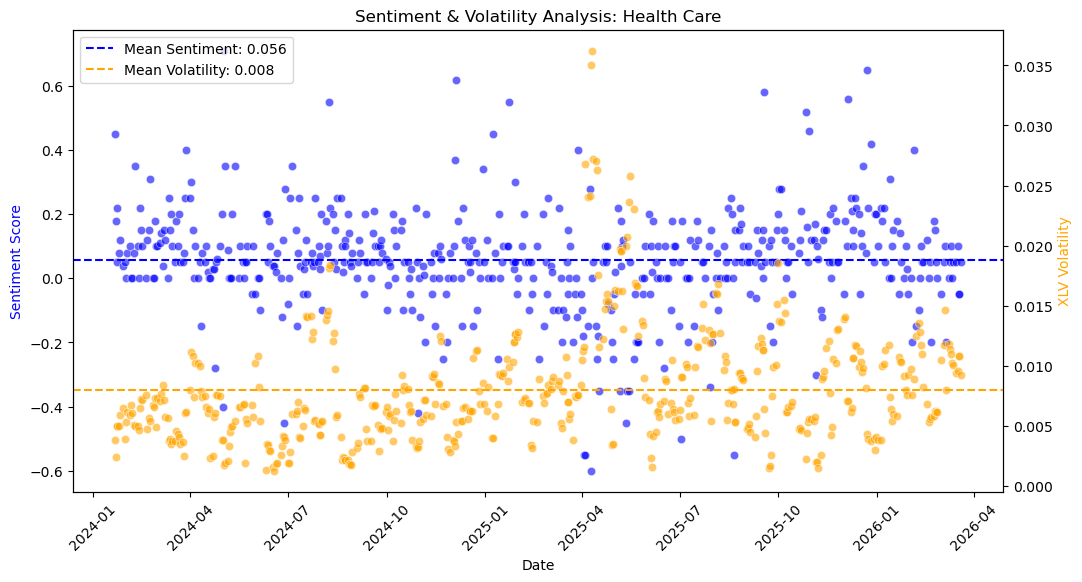

In [30]:
col_title = "Health Care"
ticker_vol_title = "XLV Volatility"

# 1. Calculate the means
sent_mean = df_clean_sorted[col_title].mean()
vol_mean = df_clean_sorted[ticker_vol_title].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot Sentiment (Left Axis)
sns.scatterplot(data=df_clean_sorted, x="Date", y=col_title, ax=ax1, color='blue', alpha=0.6)
ax1.axhline(sent_mean, color="blue", linestyle="--", label=f"Mean Sentiment: {sent_mean:.3f}")
ax1.set_ylabel("Sentiment Score", color='blue')

# 3. Create Volatility (Right Axis)
ax2 = ax1.twinx()
sns.scatterplot(data=df_clean_sorted, x="Date", y=ticker_vol_title , ax=ax2, color='orange', alpha=0.6)
ax2.axhline(vol_mean, color="orange", linestyle="--", label=f"Mean Volatility: {vol_mean:.3f}")
ax2.set_ylabel(ticker_vol_title, color='orange')

# 4. Cleanup
plt.title(f"Sentiment & Volatility Analysis: {col_title}")
ax1.tick_params(axis='x', rotation=45)

# Combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

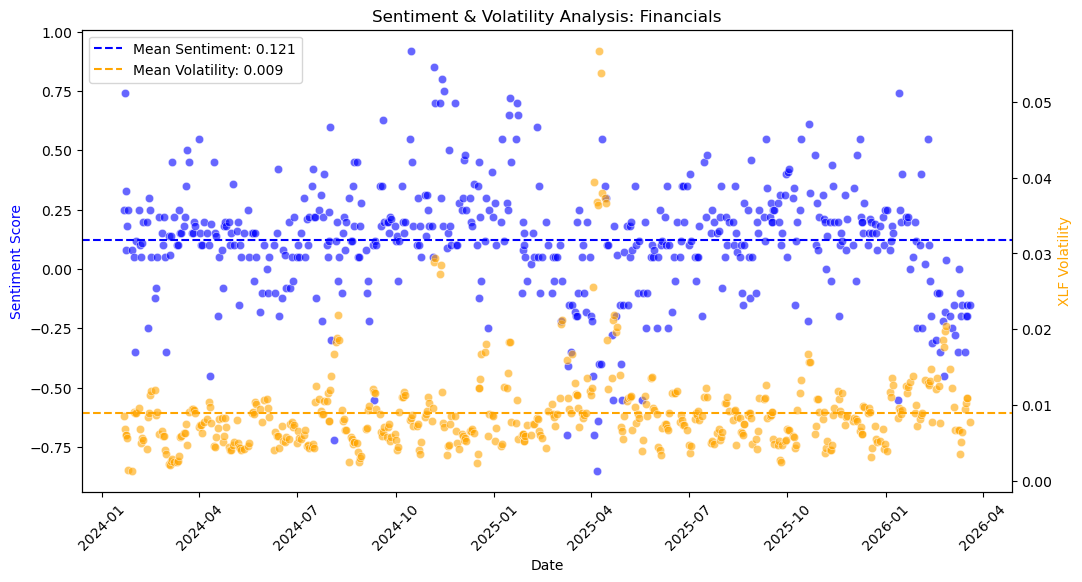

In [31]:
col_title = "Financials"

ticker_vol_title = "XLF Volatility"

# 1. Calculate the means
sent_mean = df_clean_sorted[col_title].mean()
vol_mean = df_clean_sorted[ticker_vol_title].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot Sentiment (Left Axis)
sns.scatterplot(data=df_clean_sorted, x="Date", y=col_title, ax=ax1, color='blue', alpha=0.6)
ax1.axhline(sent_mean, color="blue", linestyle="--", label=f"Mean Sentiment: {sent_mean:.3f}")
ax1.set_ylabel("Sentiment Score", color='blue')

# 3. Create Volatility (Right Axis)
ax2 = ax1.twinx()
sns.scatterplot(data=df_clean_sorted, x="Date", y=ticker_vol_title , ax=ax2, color='orange', alpha=0.6)
ax2.axhline(vol_mean, color="orange", linestyle="--", label=f"Mean Volatility: {vol_mean:.3f}")
ax2.set_ylabel(ticker_vol_title, color='orange')

# 4. Cleanup
plt.title(f"Sentiment & Volatility Analysis: {col_title}")
ax1.tick_params(axis='x', rotation=45)

# Combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

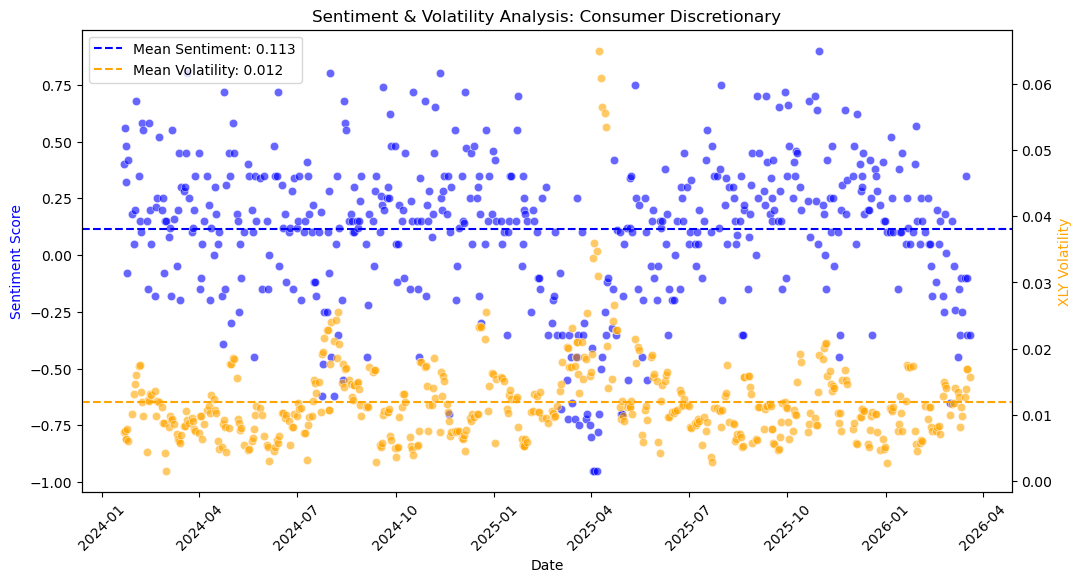

In [32]:
col_title = "Consumer Discretionary"

ticker_vol_title = "XLY Volatility"

# 1. Calculate the means
sent_mean = df_clean_sorted[col_title].mean()
vol_mean = df_clean_sorted[ticker_vol_title].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot Sentiment (Left Axis)
sns.scatterplot(data=df_clean_sorted, x="Date", y=col_title, ax=ax1, color='blue', alpha=0.6)
ax1.axhline(sent_mean, color="blue", linestyle="--", label=f"Mean Sentiment: {sent_mean:.3f}")
ax1.set_ylabel("Sentiment Score", color='blue')

# 3. Create Volatility (Right Axis)
ax2 = ax1.twinx()
sns.scatterplot(data=df_clean_sorted, x="Date", y=ticker_vol_title , ax=ax2, color='orange', alpha=0.6)
ax2.axhline(vol_mean, color="orange", linestyle="--", label=f"Mean Volatility: {vol_mean:.3f}")
ax2.set_ylabel(ticker_vol_title, color='orange')

# 4. Cleanup
plt.title(f"Sentiment & Volatility Analysis: {col_title}")
ax1.tick_params(axis='x', rotation=45)

# Combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

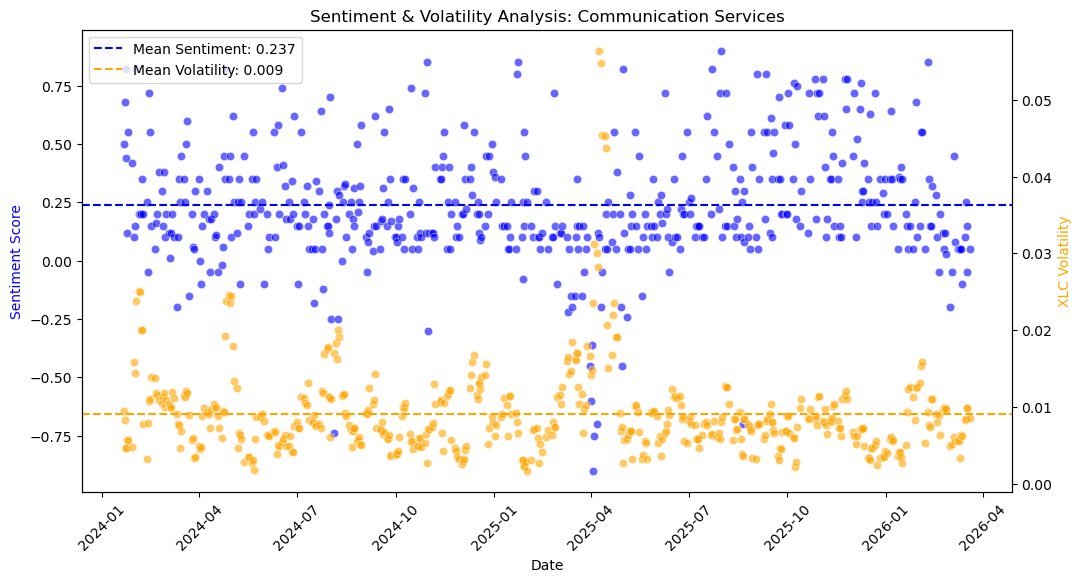

In [33]:
col_title = "Communication Services"
ticker_vol_title = "XLC Volatility"

# 1. Calculate the means
sent_mean = df_clean_sorted[col_title].mean()
vol_mean = df_clean_sorted[ticker_vol_title].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot Sentiment (Left Axis)
sns.scatterplot(data=df_clean_sorted, x="Date", y=col_title, ax=ax1, color='blue', alpha=0.6)
ax1.axhline(sent_mean, color="blue", linestyle="--", label=f"Mean Sentiment: {sent_mean:.3f}")
ax1.set_ylabel("Sentiment Score", color='blue')

# 3. Create Volatility (Right Axis)
ax2 = ax1.twinx()
sns.scatterplot(data=df_clean_sorted, x="Date", y=ticker_vol_title , ax=ax2, color='orange', alpha=0.6)
ax2.axhline(vol_mean, color="orange", linestyle="--", label=f"Mean Volatility: {vol_mean:.3f}")
ax2.set_ylabel(ticker_vol_title, color='orange')

# 4. Cleanup
plt.title(f"Sentiment & Volatility Analysis: {col_title}")
ax1.tick_params(axis='x', rotation=45)

# Combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

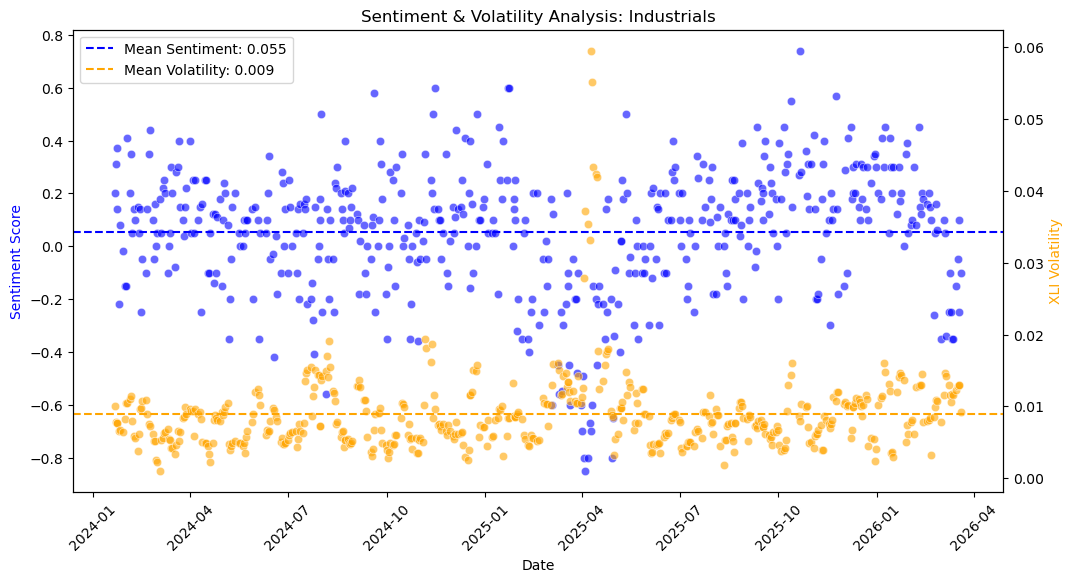

In [34]:
col_title = "Industrials"

ticker_vol_title = "XLI Volatility"

# 1. Calculate the means
sent_mean = df_clean_sorted[col_title].mean()
vol_mean = df_clean_sorted[ticker_vol_title].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot Sentiment (Left Axis)
sns.scatterplot(data=df_clean_sorted, x="Date", y=col_title, ax=ax1, color='blue', alpha=0.6)
ax1.axhline(sent_mean, color="blue", linestyle="--", label=f"Mean Sentiment: {sent_mean:.3f}")
ax1.set_ylabel("Sentiment Score", color='blue')

# 3. Create Volatility (Right Axis)
ax2 = ax1.twinx()
sns.scatterplot(data=df_clean_sorted, x="Date", y=ticker_vol_title , ax=ax2, color='orange', alpha=0.6)
ax2.axhline(vol_mean, color="orange", linestyle="--", label=f"Mean Volatility: {vol_mean:.3f}")
ax2.set_ylabel(ticker_vol_title, color='orange')

# 4. Cleanup
plt.title(f"Sentiment & Volatility Analysis: {col_title}")
ax1.tick_params(axis='x', rotation=45)

# Combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

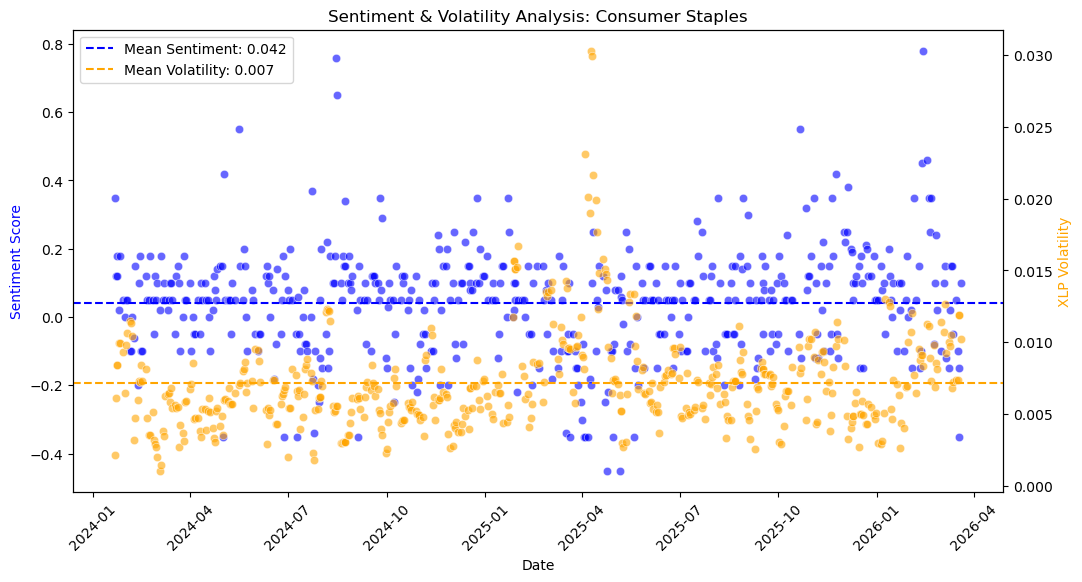

In [35]:
col_title = "Consumer Staples"

ticker_vol_title = "XLP Volatility"

# 1. Calculate the means
sent_mean = df_clean_sorted[col_title].mean()
vol_mean = df_clean_sorted[ticker_vol_title].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot Sentiment (Left Axis)
sns.scatterplot(data=df_clean_sorted, x="Date", y=col_title, ax=ax1, color='blue', alpha=0.6)
ax1.axhline(sent_mean, color="blue", linestyle="--", label=f"Mean Sentiment: {sent_mean:.3f}")
ax1.set_ylabel("Sentiment Score", color='blue')

# 3. Create Volatility (Right Axis)
ax2 = ax1.twinx()
sns.scatterplot(data=df_clean_sorted, x="Date", y=ticker_vol_title , ax=ax2, color='orange', alpha=0.6)
ax2.axhline(vol_mean, color="orange", linestyle="--", label=f"Mean Volatility: {vol_mean:.3f}")
ax2.set_ylabel(ticker_vol_title, color='orange')

# 4. Cleanup
plt.title(f"Sentiment & Volatility Analysis: {col_title}")
ax1.tick_params(axis='x', rotation=45)

# Combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

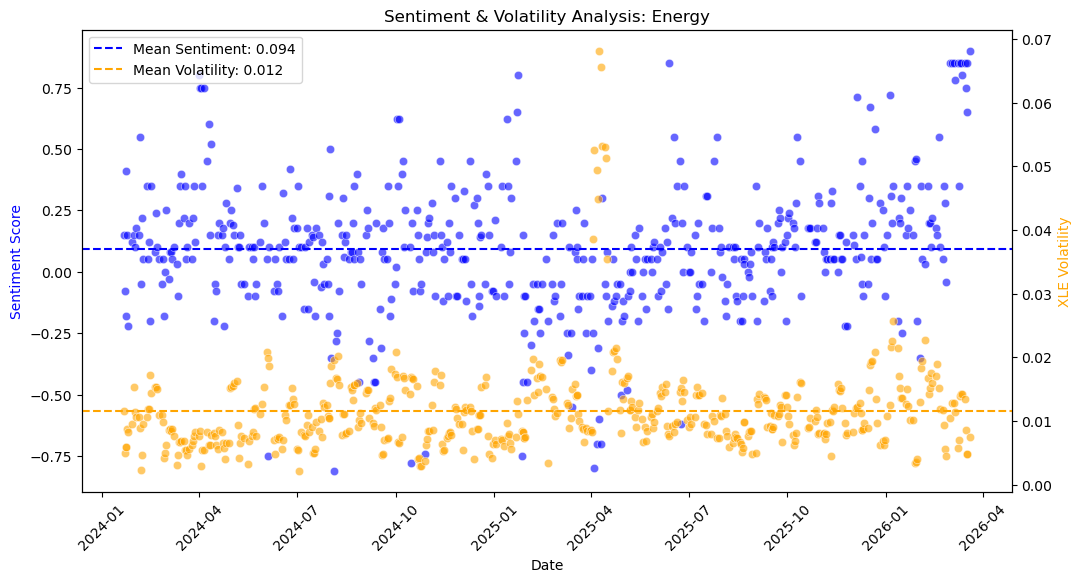

In [36]:
col_title = "Energy"

ticker_vol_title = "XLE Volatility"

# 1. Calculate the means
sent_mean = df_clean_sorted[col_title].mean()
vol_mean = df_clean_sorted[ticker_vol_title].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot Sentiment (Left Axis)
sns.scatterplot(data=df_clean_sorted, x="Date", y=col_title, ax=ax1, color='blue', alpha=0.6)
ax1.axhline(sent_mean, color="blue", linestyle="--", label=f"Mean Sentiment: {sent_mean:.3f}")
ax1.set_ylabel("Sentiment Score", color='blue')

# 3. Create Volatility (Right Axis)
ax2 = ax1.twinx()
sns.scatterplot(data=df_clean_sorted, x="Date", y=ticker_vol_title , ax=ax2, color='orange', alpha=0.6)
ax2.axhline(vol_mean, color="orange", linestyle="--", label=f"Mean Volatility: {vol_mean:.3f}")
ax2.set_ylabel(ticker_vol_title, color='orange')

# 4. Cleanup
plt.title(f"Sentiment & Volatility Analysis: {col_title}")
ax1.tick_params(axis='x', rotation=45)

# Combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

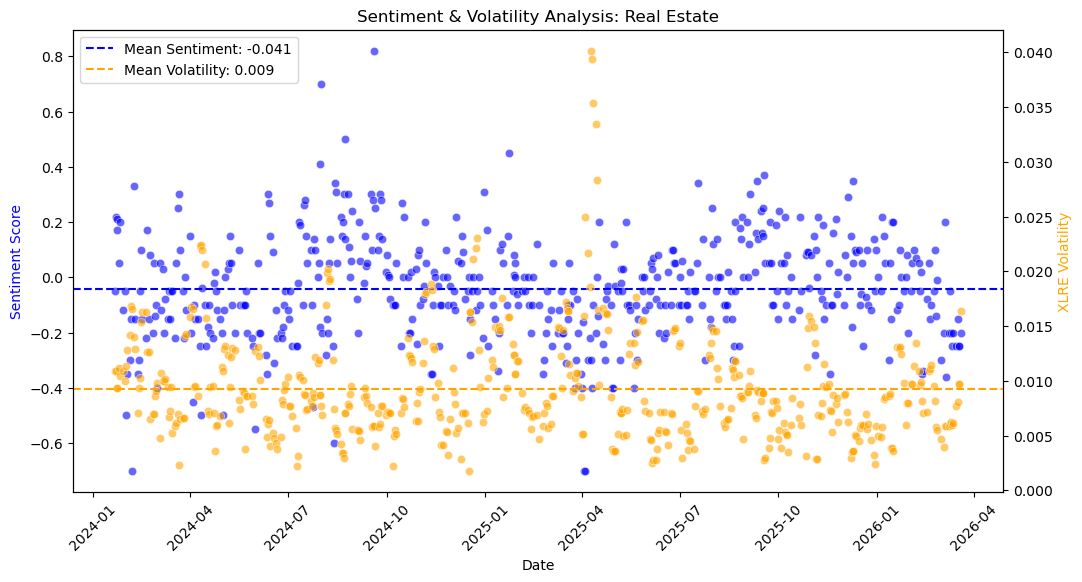

In [37]:
col_title = "Real Estate"

ticker_vol_title = "XLRE Volatility"

# 1. Calculate the means
sent_mean = df_clean_sorted[col_title].mean()
vol_mean = df_clean_sorted[ticker_vol_title].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot Sentiment (Left Axis)
sns.scatterplot(data=df_clean_sorted, x="Date", y=col_title, ax=ax1, color='blue', alpha=0.6)
ax1.axhline(sent_mean, color="blue", linestyle="--", label=f"Mean Sentiment: {sent_mean:.3f}")
ax1.set_ylabel("Sentiment Score", color='blue')

# 3. Create Volatility (Right Axis)
ax2 = ax1.twinx()
sns.scatterplot(data=df_clean_sorted, x="Date", y=ticker_vol_title , ax=ax2, color='orange', alpha=0.6)
ax2.axhline(vol_mean, color="orange", linestyle="--", label=f"Mean Volatility: {vol_mean:.3f}")
ax2.set_ylabel(ticker_vol_title, color='orange')

# 4. Cleanup
plt.title(f"Sentiment & Volatility Analysis: {col_title}")
ax1.tick_params(axis='x', rotation=45)

# Combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

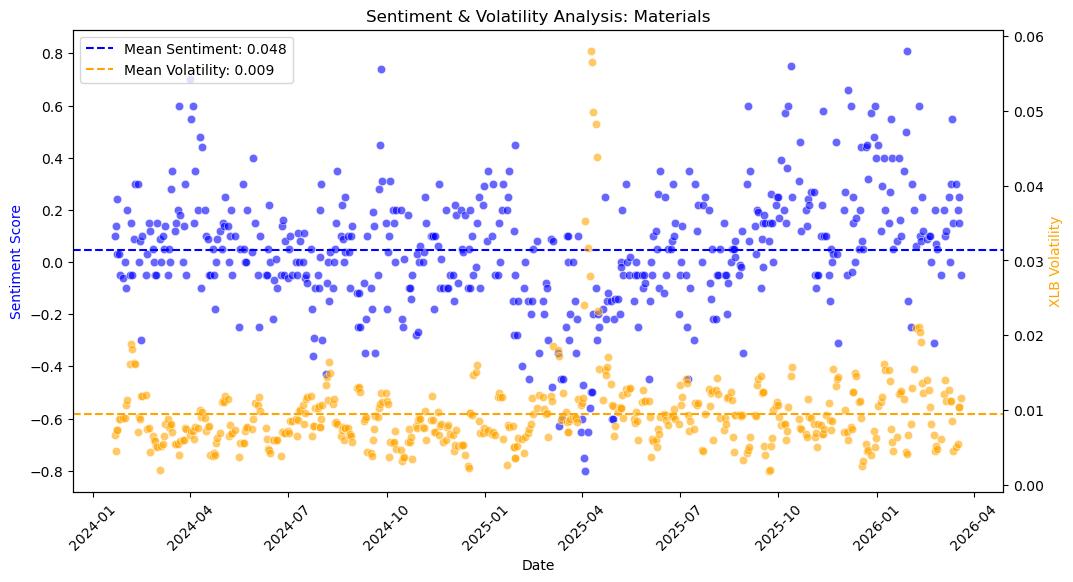

In [38]:
col_title = "Materials"

ticker_vol_title = "XLB Volatility"

# 1. Calculate the means
sent_mean = df_clean_sorted[col_title].mean()
vol_mean = df_clean_sorted[ticker_vol_title].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Plot Sentiment (Left Axis)
sns.scatterplot(data=df_clean_sorted, x="Date", y=col_title, ax=ax1, color='blue', alpha=0.6)
ax1.axhline(sent_mean, color="blue", linestyle="--", label=f"Mean Sentiment: {sent_mean:.3f}")
ax1.set_ylabel("Sentiment Score", color='blue')

# 3. Create Volatility (Right Axis)
ax2 = ax1.twinx()
sns.scatterplot(data=df_clean_sorted, x="Date", y=ticker_vol_title , ax=ax2, color='orange', alpha=0.6)
ax2.axhline(vol_mean, color="orange", linestyle="--", label=f"Mean Volatility: {vol_mean:.3f}")
ax2.set_ylabel(ticker_vol_title, color='orange')

# 4. Cleanup
plt.title(f"Sentiment & Volatility Analysis: {col_title}")
ax1.tick_params(axis='x', rotation=45)

# Combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

In [ ]:
""" 
Note the systemic drop in sentiment April 2025
Liberation Day Tariffs were on 04-02-2025

Tariffs took effect on April 5, 2025

"""

In [ ]:
""" 
Do a simple linear regression with volatility vs sentiment scores , regime change detected by outliers detection

"""